<a href="https://colab.research.google.com/github/QwertyJacob/colab_handouts_PSI/blob/main/BONUSX_ActiveInference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A hopefully simple tutorial on Active inference for continuous PO-MDPs
_______
By Jesus Cevallos


## Markov Decision Processes

### Why we need Markov Decision Processes



Imagine an agent — a robot, an animal, or even a thermostat — that interacts with an environment over time.  
At each moment:

- The environment has **some state**, describing what is going on.
- The agent takes **an action**.
- The environment changes in response.
- The agent receives **feedback** (in reinforcement learning) or *perceptions* (in active inference).

To reason about such interactions, we need a mathematical model that:

- Represents how the world evolves over time  
- Represents how the agent influences the world  
- Allows us to compute or infer how good (or *expected*) different action sequences are  

The simplest such model is a **Markov Decision Process (MDP)**.

### What is a Markov Decision Process?

An MDP is defined by:

$$
\mathcal{M} = (\mathcal{S},\mathcal{A},P(s_{t+1}\mid s_t, a_t), R(s_t,a_t))
$$

Where:

- **$\mathcal{S}$** is the set of possible *states* of the world  
- **$\mathcal{A}$** is the set of possible *actions* the agent can take  
- **$P(s_{t+1} \mid s_t, a_t)$** is the probability of transiting to $s_{t+1}$ given the current state $s_t$ and that the agent takes action $a_t$ 
- **$R(s_t,a_t)$** (only in RL) is a reward function  

### The Markov Property






The key assumption that makes MDPs simple and powerful is:

$$
\text{The future depends only on the present, not on the whole past.}
$$

Formally, if we use $s_{0:t}$ to denote the sequence of past states up to time $t$, and $a_{0:t}$ to denote the sequence of past actions up to time $t$, then the Markov assumption says that:

$$
P(s_{t+1} \mid s_{0:t}, a_{0:t}) = P(s_{t+1} \mid s_t, a_t).
$$

This is a *memorylessness* assumption.  
The idea is: **the present state summarizes all relevant information about the past**.

This dramatically simplifies computations.

Without the Markov assumption, state prediction would require the entire history, which is computationally explosive.

### The Graphical (Causal) Structure of an MDP



An MDP can be expressed as a causal diagram:

![](figs/pgm_mdp.png)

Where the arrows mean “causes” or “influences”.

More explicitly:

- The state at time $t$, $s_t$ causes the next state  $s_{t+1}$
- The action $a_t$ also contributes causally to  $s_{t+1}$
- The overall transition to $s_{t+1}$ is described by $P(t+1|s_t,a_t)$

MDPs are called **fully observable** because states are supposed to be visible (i.e. known to the agent)

### Why MDPs Are Not Enough



MDPs assume the agent *sees* the world’s true state $s_t$.

But in real life:

* A robot only sees sensor readings
* A human only perceives noisy sensory data
* A self-driving car sees camera images, not true distances
* A rat navigating a maze does not know which room it is in with certainty

In all realistic situations, the agent receives **uncertain** or **indirect** information about the true state.

This motivates **Partially Observed MDPs (POMDPs)**.

### From MDPs to POMDPs: The Need for Hidden States



In a POMDP, the agent receives **observations**:

* $o_t$ is what the agent *observes*
* $s_t$ is the true (hidden) state
* There is a mapping (likelihood model)
  $$
  P(o_t \mid s_t)
  $$

This makes the problem **much more realistic**, because it models:

* sensor noise
* perceptual ambiguity
* incomplete information
* uncertainty about what is happening


### Formal Structure of a POMDP



A POMDP is:

$$
\mathcal{P} = (\mathcal{S}, \mathcal{A}, \mathcal{O},
P(s_{t+1}\mid s_t,a_t), P(o_t\mid s_t))
$$

Differences from MDP:

* Observations $o_t$ are noisy functions of hidden states
* Agent must **infer** states from observations
* This leads to beliefs, filtering, and Bayesian inference

In other words, we go from:

MDP:
**State is known → choose action**

POMDP:
**State is unknown → infer hidden state → choose action**


### The Causal Graph of a POMDP



A POMDP can be visualised also through  a probabilistic graphical model as the one below:

![](figs/pgm_pomdp.png)

* Hidden states cause observations
* Hidden states evolve based on actions
* Note: you decide what actions to take based on inferred states, i.e. the only information you got is observations.

This structure is **exactly** the generative model used in active inference.


### Conditional Independences in POMDPs




The heart of the POMDP structure is the **conditional independence** that hidden states enforce:

#### Observations depend only on the current hidden state

$$
 P(o_t \mid s_t, a_{t-1}, s_{t-1}, o_{t-1}, \ldots) = P(o_t \mid s_t)
$$

Meaning:

> Once you know the current hidden state, the observation no longer depends on the past. 

Note that observation $o_t$ is also independent of actions $a_{0:t-1}$  given state $s_t$.


This is a **causal shielding** property.

#### State transitions depend only on current state and action

$$
P(s_{t+1} \mid s_t, a_t, s_{t-1}, o_{t-1}, \ldots) = P(s_{t+1} \mid s_t, a_t)
$$

The hidden state encodes all relevant information for prediction. (We do not care about previous observations either)

## The Generative Process vs. The Generative Model



Up to this point, we've described the **generative process**: the actual, external dynamics of the world as modeled by a POMDP. This is the "true" mechanism by which hidden states evolve, actions influence those states, and observations are generated. In the generative process, we use probabilities denoted by $P$, such as $P(s_{t+1} \mid s_t, a_t)$ for state transitions and $P(o_t \mid s_t)$ for the likelihood of observations given states.

However, the agent (e.g., a robot or animal) does not have direct access to this true process. Instead, the agent maintains an internal **generative model**: a probabilistic representation of how it *believes* the world works. This model allows the agent to infer hidden states from observations, predict future outcomes, and plan actions. The generative model is "specular" (mirror-like) to the generative process—it has a similar structure—but it represents the agent's subjective beliefs, which may approximate or diverge from the true process.

In active inference, we denote the distributions in the generative model with $Q$ to distinguish them from the true $P$ distributions of the process. For example:
- $Q(s_{t+1} \mid s_t, a_t)$ approximates the state transition.
- $Q(o_t \mid s_t)$ approximates the observation likelihood.

The key difference:
- **Generative Process ($P$)**: The objective, external world dynamics (often unknown to the agent).
- **Generative Model ($Q$)**: The agent's internal, subjective model used for inference and decision-making. It is learned or updated over time to better match the process.

### Factorization Under the Markovian Assumption



Under the Markovian assumption (as in the POMDP structure), the generative model factorizes according to the conditional independencies in the causal graph. This means the joint probability breaks down into simpler, local conditional distributions, making computations tractable.

Recall the POMDP causal structure: Hidden states evolve based on previous states and actions, and observations depend only on the current hidden state. Actions are chosen based on inferred states (via a policy, which we'll discuss later).

The factorization of the generative model is:
$$
Q(s_{0:T}, a_{0:T}, o_{0:T}) = Q(s_0) \prod_{t=0}^{T-1} Q(s_{t+1} \mid s_t, a_t) \cdot Q(a_t \mid s_t) \cdot \prod_{t=0}^{T} Q(o_t \mid s_t)
$$

Breaking it down:
- $Q(s_0)$: Prior belief over the initial hidden state.
- $Q(s_{t+1} \mid s_t, a_t)$: Believed state transition model (Markovian: depends only on current state and action).
- $Q(a_t \mid s_t)$: The agent's policy, specifying actions given inferred states.
- $Q(o_t \mid s_t)$: Likelihood model (observations depend only on the current hidden state).

This factorization mirrors the generative process but uses $Q$ to reflect the agent's approximate beliefs. The Markovian property ensures that each term depends only on immediate predecessors, "shielding" the future from the distant past.

### Model Inversion: Inferring Hidden States via Bayes' Theorem



Once the agent has initialized its **generative model** $Q(s_{0:T}, a_{0:T}, o_{0:T})$, its primary task is to **invert** this model to infer the hidden states that best explain the observed data. This inversion is the core of perception in active inference and is performed using **Bayes' theorem**.

Let:
- $\underline{o} \triangleq o_{0:t}$: the sequence of past observations (including current time $t$),
- $\underline{a} \triangleq a_{0:t-1}$: the sequence of past actions ( we exclude $a_t$ because that represent's the immediate future action taken after inferring $s_t$)

The agent wants to compute the **posterior belief** over the current hidden state $s_t$ (denoted $s_t$ for current time) given all past observations and actions:
$$
Q(s_t \mid \underline{o}, \underline{a})
$$

This posterior represents the agent's **inferred belief** about the current state of the world.

### Bayesian Model Inversion



Using Bayes' theorem in the generative model:

$$
\boxed{
Q(s_t \mid \underline{o}, \underline{a})
= \frac{Q(\underline{o} \mid \underline{a}, s_t) \cdot Q(s_t \mid \underline{a})}{Q(\underline{o} \mid \underline{a})}
}
$$

This is **exact Bayesian inference** within the agent's internal model:
- $Q(\underline{o} \mid \underline{a}, s_t)$: **Likelihood** — how well the current state would explain the observations (via $Q(o_t \mid s_t)$).
- $Q(s_t \mid \underline{a})$: **Prior** — the predicted state under the agent's past actions.
- $Q(\underline{o} \mid \underline{a})$: **Model evidence** (marginal likelihood) — normalizes the posterior.


### Exploiting Conditional Independence (Markov Structure)




Thanks to the **Markovian assumptions** in the generative model, many terms become conditionally independent. In particular:
- Each observation $o_t$ depends **only** on its contemporaneous state $s_t$,
- Each state transition $s_{t+1}$ depends **only** on $s_t$ and $a_t$.

This allows us to simplify the likelihood:
$$
Q(\underline{o} \mid \underline{a}, s_t) = Q(\underline{o} \mid s_t) = \prod_{k=0}^{\tau-1} Q(o_k \mid s_k)
$$

So the full posterior becomes:

$$
\boxed{
Q(s_t \mid \underline{o}, \underline{a})
= \frac{
\overbrace{Q(\underline{o} \mid s_t)}^{\text{likelihood over all obs}}
\cdot
\overbrace{Q(s_t \mid \underline{a})}^{\text{prior state distribution}}
}{
\underbrace{Q(\underline{o} \mid \underline{a})}_{\text{marginal likelihood or evidence}}
}
} \tag{1}
$$

The **marginal likelihood** of the observations under the agent’s generative model, in principle is the result of a marginalisation (hence the name):

$$
Q(\underline{o} \mid \underline{a}) = \int Q(\underline{o}, s_t \mid \underline{a}) \, ds_t
= \int \underbrace{Q(\underline{o} \mid s_t)}_{\text{likelihood}} \cdot \underbrace{Q(s_t \mid \underline{a})}_{\text{prior over trajectories}} \, ds_t
$$

This is a **high-dimensional integral** over all possible states $s_t$. For even moderately discrete or continuous state spaces, this integral is **intractable** — it cannot be computed exactly.

Thus, **exact Bayesian inference** is generally infeasible in real-time agents.

### A useful approximation:



To make inference tractable, we introduce a **_variational_ distribution** $q_{\underline{o}}(s_t\mid \underline{a})$ — a simpler, factorized family of distributions whose PDF will be a function of $\underline{o}$. (We would say that $\underline{o}$ are sufficient statistics for $q$). This parameterized distribution **approximates** the true posterior $Q(s_t \mid \underline{o}, \underline{a})$. We restrict $q_{\underline{o}}(s_t\mid \underline{a})$ to a family of distributions that are easy to evaluate and update (e.g., mean-field, Gaussian, recurrent neural network approximations).

The goal: **minimize the difference** between $q_{\underline{o}}(s_t\mid \underline{a})$ and the true posterior:

$$
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]   \rightarrow 0 \tag{2}
$$

But we can't directly minimise this divergence because the true posterior, $ Q(s_t \mid \underline{o}, \underline{a})$ is unknown because it itself depends on the intractable evidence $Q(\underline{o} \mid \underline{a})$!

(Notice that, if $ Q(s_t \mid \underline{o}, \underline{a})$ were computable, we would not be talking about variational inference at all!)

So we will minimise $(2)$ indirectly by minimising a quantity that we call Variational Free Energy. To see how, let's take a closer look to the KL divergence in $(2)$:

$$
\begin{aligned}
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]   &=
    \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(s_t \mid \underline{o}, \underline{a}) \right]\\\\
    &\text{using the definition of conditional probability: }\\
    &\left( Q(s_t \mid \underline{o}, \underline{a})=
                \frac{
            Q(\underline{o}, s_t \mid \underline{a})
            }{
            Q(\underline{o} \mid \underline{a})
            }
    \right)\\
    &\left( \ln Q(s_t \mid \underline{o}, \underline{a})=
            \ln Q(\underline{o}, s_t \mid \underline{a}) - \ln Q(\underline{o} \mid \underline{a})\right) \\\\
     &\text{substituting this into the KL divergence:}\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) + \ln Q(\underline{o} \mid \underline{a}) \right]\\\\
    &\text{The third term can get out of the expectation (it does not contain $s_t$):}\\
    &=\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) -\ln Q(\underline{o}, s_t \mid \underline{a})\right] + \ln Q(\underline{o} \mid \underline{a}) \\\\
    &\text{By definition of KL divergence:}\\
    &=D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]+ \ln Q(\underline{o} \mid \underline{a})
\end{aligned}
$$

Let's look again to the identity we have just found, let's add some names to the terms in this expression:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}}  =
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}+ \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{log evidence}}
$$

This tell's us that, even if we are not able to minimise the approximation error directly, **we can minimise the approximation error vicariously by minimising Variational Free Energy (VFE)**, whatever the VFE actually is.

Let's also put in evidente the log-evidence, which we know is a good thing to maximise (its a good thing to shape $Q$ so that it aligns to what has actually happen, i.e., $\underline{o}$ and $\underline{a}$):

$$

    \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{log evidence}} =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}}  - \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
$$

Looking things from this point of view, we are even more convinced that minimising the VFE is actually a good idea: it will maximise the evidence of our generative model!

Now, the only question is, what a heck is the VFE? Let's put a second in evidence this term:

$$
    \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
    =  \underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}} - \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{log evidence}}}  
$$

We now see that the VFE is an **upper bound** (KL divergence is non-negative by definition) on the _negative of the log evidence_ (which is also called _surprisal_). Therefore, if we need to maximise evidence to construct a good generative model, we should _minimise surprisal_. Again, this expression convinces us that by minimising the VFE _functional_ (a functional is a function of a function), we are vicariously minimising "surprise", because the VFE is an upper bound on it. 

Let's change the sing of both terms of the equation for a final consideration:

$$
    -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a})\right]}_{\textit{Variational Free Energy}}
    =  -\underbrace{D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{o}, \underline{a})  \right]}_{\text{Approximation error}} + \underbrace{\ln Q(\underline{o} \mid \underline{a})}_{\text{\textit{log evidence}}}  
$$

We now see that the negative of the VFE is a lower bound of the evidence. In fact, ML fellas call the "Evidence Lower Bound" or ELBo to the negative of VFE. This means that, if we maximise the negative of the VFE (minimise the VFE!), we maximise the Evidence.

## The Variational Free Energy:

Now that the are convinced that using the VFE may be useful in the context of optimal control, let's study the term individually. Let's decompose it so that we can better understand it. 

From the derivation above, we know that the Variational Free Energy is a KL divergence:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \tag{3}
$$



There are many ways to understand such a divergence, depending on how we factorise it. Let's start by the followig factorisation:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&
= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
& = - \underbrace{\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}_{\text{Neutrality}} - \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})}_{\text{Consistency}}]
\end{aligned}
\tag{3.1}
$$

The first way of understanding the VFE $(3.1)$ is looking it as the summation of two terms:

a) **The negative entropy of the variational distribution**, $- {\mathbb{H}[q_{\underline{o}}(s_t\mid \underline{a})]}$:

The entropy is a measure of neutrality, a measure of spread. The more entropy, the less specific our distribution is, and so it may accomodate a bigger set of distributions. 

When we are fitting an unknown distribution, we should maximise the entropy a priori. This the maximum entropy principle, a well-noted principle in many fields of physics, neuroscience and information theory. Linked to the principle of [parsimony in intelligence](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=11292729). 

Now following the Max Ent principle takes us minimise the VFE, so VFE minimisation is a good thing to do also from the point of view of this principle.


b) **The negative cross-entropy of the joint with respect to the variational distribution**, $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$:

The joint distribution used here $Q(\underline{o}, s_t \mid \underline{a})$ is an interesting signal: it tells us what is the probability of our current generative model $Q$ displaying or predicting that the sequence of actions we have observed until now, $\underline{o}$ corresponds to beign in state $s_t$ given the sequence of actions taken so far $\underline{a}$. Due to the fact that both $\underline{o}$ and $\underline{a}$ actually occurred, then maximising $Q(\underline{o}, s_t \mid \underline{a})$ is a good idea because it speaks to maximising the precision of our generative model.

Furthermore, $Q(\underline{o}, s_t \mid \underline{a})$ is inside an expectation, and the distribution we are computing this expectation over is precisely $q_{\underline{o}}(s_t\mid \underline{a})$, i.e., our approximate posterior distribution, which is supposed to approximate the real posterior, i.e. $P(s_t \mid \underline{o}, \underline{a})$. At this point we can make two different observations:

  - **b.1)** Suppose that at a certain moment during training, our approximate posterior is fit, i.e., it approximates well our real posterior:

$$
    D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || P(s_t \mid \underline{o}, \underline{a})  \right]   \approx 0 
$$
In this case, we could take $q_{\underline{o}}(s_t\mid \underline{a})$ as is, and try to shape our generative model so that $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}[Q(\underline{o}, s_t \mid \underline{a})]$ is maximised. 
  
  - **b.2)** Specularly, assuming that, for any reason, $Q(\underline{o}, s_t \mid \underline{a})$ is fit at a certain moment, then we could try to modify $q_{\underline{o}}(s_t\mid \underline{a})$ to maximise the expectation above.

Both things happen in Expectation-Maximisation algorithms in machine learning, and active inference may include these dynamics oftentimes. Intuitively, it is a good thing to maximise this _consistency_ term, either by shaping $Q$ or $q_{\underline{o}}$ (or both), and that dynamic also backs up our VFE minimisation imperative, because the consistency has a minus sign in (3.1).

Let's look at a second way of expressing the VFE:

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(\underline{o}, s_t \mid \underline{a}) \right] \\
&
= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t, \underline{a}) - \ln Q(s_t \mid \underline{a})\right] \\
\text{By virtue }&\text{of the Markovianity assumption we have that }\\
&\qquad Q(\underline{o} \mid s_t, \underline{a}) = Q(\underline{o} \mid s_t) \qquad \text{so:}\\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o} \mid s_t) - \ln Q(s_t \mid \underline{a})\right] \\
& = \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a})  - \ln Q(s_t \mid \underline{a}) \right]- \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[\ln Q(\underline{o} \mid s_t)\right] \\
& =  \underbrace{D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]}_{\text{Complexity}} - \underbrace{\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]}_{\text{Accuracy}} \\
\end{aligned}
\tag{3.2}
$$

1) here the **complexity** term $D_{KL} \left[ q_{\underline{o}}(s_t\mid \underline{a}) || Q(s_t \mid \underline{a}) \right]$ is measuring the divergence between our approximate posterior and the prior of our generative model. Again, expectation maximisation can be used here to _minimise_ this divergence by acting on either the former or the latter. In any case, this divergence measures how much "work" the agent  should do in its artificial minds, to build a good posterior informed by evidence, or a good generative model informed by a solid posterior, which describes the distribution of states given a course of past actions. **Take out:** Intuitively, minimising such divergence is a good thing to do. Just consider: the assumption is to start at a same state $s_0$, then we now we have taken a unique course of actions $\underline{a}$, so the state we are now according to $q_{\underline{o}}(s_t\mid \underline{a})$ and $Q(s_t \mid \underline{a})$ should be the same. Note that minimising complexity entails minimising the VFE. Check.

2) The **accuracy** $\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln Q(\underline{o} \mid s_t) \right]$ is more of an _expectation of evidence_. Again, expectation maximisation tells us we could see this as an opportunity to maximise our model or our posterior, or both. This term is similar to the consistency one in (3.1) in that is is a measure of precision that needs to be maximised. Again, we have the negative accuracy in (3.2), so maximising accuracy provokes EFE minimisation. Check again. 


> Take away, we can use eiter $(3.1)$ or $(3.2)$ in our experiments as a ground truth signal that gives us a _bayes-optimal_ way of using our generative model at each moment.

### A note on the per-step VFE

So far we have written the VFE as a functional of an entire history of observations
and actions, $\underline{o}$ and $\underline{a}$:

$$
VFE = D_{KL}\left[ q_{\underline{o}}(s_t\mid \underline{a}) \,\|\, Q(\underline{o}, s_t \mid \underline{a}) \right]
$$

Before moving beyond in our tutorial, it is worth pausing to ask:
**does the VFE make sense one time step at a time?**
The answer is yes, and in two independent ways.


#### 1. Validity per se

Nothing in the definition of the VFE requires a full history.
At any single time step $\tau$, we can define a one-step VFE by simply
restricting all quantities to that step:

$$
VFE_\tau \triangleq D_{KL}\left[ q_{o_\tau}(s_\tau\mid a_{\tau-1}) \,\|\,
Q(o_\tau, s_\tau \mid a_{\tau-1}) \right]
$$

This object is well-formed: $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ is a valid
probability distribution over $s_\tau$, and $Q(o_\tau, s_\tau \mid a_{\tau-1})$
is a valid joint. The same algebra we carried out for the full VFE applies
verbatim, and yields the same bound on single-step surprisal:

$$
VFE_\tau = - \ln Q(o_\tau \mid a_{\tau-1}) + D_{KL}\left[
q_{o_\tau}(s_\tau \mid a_{\tau-1}) \,\|\, Q(s_\tau \mid o_\tau, a_{\tau-1})
\right] \geq - \ln Q(o_\tau \mid a_{\tau-1})
$$

The per-step VFE is therefore not an approximation or a special case — it is
the same object, just evaluated at a single timestep.

#### 2. Consistency with the Markovian factorization under mean-field approximation:

The second justification comes from the structure we already imposed on the
generative model. Under the Markov assumption, the full joint factorizes as:

$$
Q(\underline{o},\, \underline{s} \mid \underline{a})
= Q(s_0)\prod_{\tau=0}^{t-1} Q(s_{\tau+1} \mid s_\tau, a_\tau)
\prod_{\tau=0}^{t} Q(o_\tau \mid s_\tau)
$$

Taking the log turns this product into a sum:

$$
\ln Q(\underline{o},\, \underline{s} \mid \underline{a})
= \ln Q(s_0)
+ \sum_{\tau=0}^{t-1} \ln Q(s_{\tau+1} \mid s_\tau, a_\tau)
+ \sum_{\tau=0}^{t} \ln Q(o_\tau \mid s_\tau)
$$

Analogously, if we adopt a mean-field variational posterior that also factorizes
over time, we have:

$$q_{\underline{o}}( {s}_t | \underline{a}) = q_{o_0}(s_0)\prod_{\tau=1}^t q_{o_\tau}(s_\tau | a_{\tau-1}) \tag{Mean-field approximation}$$

then the KL divergence of a
product can be written as a sum of KL divergences:

$$
VFE = D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] = \sum_{\tau=0}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] = \sum_{\tau=0}^t VFE_\tau
$$
where
$$
VFE_0 = D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right]
$$
In other words, the full-sequence VFE is the **sum of per-step VFEs** — each
term contributing the local surprisal and complexity cost at its own timestep.
The Markov structure does not just permit a per-step VFE; it actively implies that
the full VFE *is nothing other than* an accumulation of per-step VFEs.

---

Both perspectives will matter in what follows. The first tells us that we could actually evaluate the VFE formula at hypothetical *future* timesteps. The second tells us that this is not an
arbitrary move: it respects the same Markovian factorization that underlies the
entire generative model.

## The Expected Free Energy (EFE)


So far so good, we've seen how to build a structure for implementing an agent (the MDP), how to make that structure more compliant with uncertainty (the POMDP), and how to update the generative model of an agent (minimising the VFE).

Now the thing is, we've so far talked about retroscpectively updating such a model to be consistent with a series of PAST observations, actions and states.

It turns out that an AGENT also ACTS, i.e., it not only passively observes "evidence" but it could also actively "drive" the course of its future observations!

Taking into account this prospective side of agency makes things interesting when adopting the bayesian framework we are doing.

In particular, we could impose a distribution of observations that  our agent oughts to see periodically, being aware of the fact that it cannot directly steer its observations but can only vicariously drive these through actions.

By using this language, we can say that an intelligent or compliant agent is the one who acts to succesfully achieve some observations. This formulation is akin to cybernetics, or, in other words, the phisiology of artificial agents: **To exist, an agent has to maintain itself on a steady state, which is described by a precise distribution of observations.** There might be fluctuations derived form the environment that would drive it away from this distribution, that would drive it to "death" or "malfunction", unless it actively mitigates this phenomena, pushing itself back to the permisible distribution of states/observations.

In other words, when we speak about the next or future actions, we could use our VFE bayesian machinery to choose the best actions to make as beign the ones which minimise the VFE _in the future_. The VFE in the future is called the _Expected Free Energy_ and is the last functional we study in this tutorial as a criterion for _policy shaping_, i.e., for _shaping the function that chooses actions_.

### Looking forward

The expected free energy can be seen as the expectation of variational free energy over a sequence of future states and observations before we actually see them. The unique thing to keep in mind is that these future observations are provoked by a sequence of actions, and that the future observations themselves provoke a future sequence of actions and states. To keep such a causality chain as correct as possible we clarify where we are now in terms of time:

- suppose we are now at instant $t$.
- we want to plan the future $h+1$ actions. (we say that $h$ is our _planning horizon_)
- we can see $o_t$, and we can _infer_ $s_t$ using model inversion, as explained before.
- we want to choose the next action, which is actually $a_t$ (not $a_{t+1}$). Indeed, our initial state was $s_0$, the initial obsrvation was $o_0$, and the initial action, taken while being at $s_0$ and after observing $o_0$ was $a_0$. Hence actions are one-step backwards: $a_0$ provokes $s_1$ and $s_1$ provokes $o_1$...
- if we where to choose not only our next action, $a_t$ but a next sequence of $h+1$ actions, then we want to choose $a_t, a_{t+1}, a_{t+2},... a_{t+h}$
- so we denote $\bar{a} = \{a_t,a_{t+1},...a_{t+h}\}$ and those fellas will generate $s_{t+1}, s_{t+2}, ..., s_{t+h+1}$
- so we use $\bar{s} = s_{t+1:t+h+1}$ for the sequence of future latent states in the planning horizon.
- those latent states will generate  $o_{t+1}, o_{t+2}, ..., o_{t+h+1}$, so we use $\bar{o} = o_{t+1:t+h+1}$ denote the sequence of the future observations.

Summary:

$$
\boxed{
\begin{aligned}
\bar{a} &\triangleq  a_{t:t+h}\\
\bar{s} &\triangleq  s_{t+1:t+h+1}\\
\bar{o} &\triangleq  o_{t+1:t+h+1}\\
\end{aligned}
}
$$

The EFE is **a kind of** expectation of the VFE under a new distribution, namely, $Q( \bar{o}, \bar{s} | \bar{a})$, which is the joint distribution of a future sequence of observations, $\bar{o}$, and a future sequence of states $\bar{s}$, given a future sequence of actions $\bar{a}$:

$$
\begin{aligned}
VFE &= \mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\\\\
&\text{Taking an expectation of VFE over the future:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE] \\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[\mathbb{E}_{q_{\underline{o}}(s_t\mid \underline{a})}\left[ \ln q_{\underline{o}}(s_t\mid \underline{a}) - \ln Q(\underline{o}, s_t \mid \underline{a}) \right]\right]\\
\end{aligned}
$$

We are basically computing an expectation of the variational free energy that would result out of a sequence of future observations and states (generated by a sequence of future actions) under our current generative model.


Notice we are **not using the equals sign here* ($=$) on purpose, because we are not yet defining what the EFE functional is, we are just describing the intuition that shapes it, this is a kind of proto functional that will later be refined to become what we will call the EFE functional.

The ($\equiv$) functor here means equivalence. It is not a strict identity, it is a more parsimonious or less aggressive form of establishing a same thing is referenced by two distinct notations. Here we are using it to say that the EFE is *something like an expectation of the VFE, but not strictly an expectation.*

Recall that the VFE is an expectation over the distribuion $q_{\underline{o}}(s_t | \underline{a})$, which depends on a sequence of past actions, $\underline{a}$, and a sequence of past observations, $\underline{o}$.

$$
\begin{aligned}
VFE &= D_{KL}\left[ q_{\underline{o}}( {s}_t | \underline{a}) \,\|\, Q(\underline{o}, \underline{s} \mid
\underline{a}) \right] \\
&= D_{KL}\left[ q_{o_0}(s_0 )\,\|\, Q(o_0,s_0) \right] + \sum_{\tau=1}^t D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\\
&= \mathbb{E}_{q_{o_0}(s_0)}  [\ln q_{o_0}(s_0) - \ln Q(o_0,s_0)] + \sum_{\tau=1}^t \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})} \left[  \ln  q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau, s_\tau \mid a_{\tau-1}) \right] \\

\end{aligned}
$$




One thing to note when we talk about the EFE is that, in the future, $\underline{o}$ will be what in the present we refer to as $\bar{o}$. Which, in other words, can be rephrased as: "the future observations, in the future, will be the present observations". Not only, but also:

> If we are in instant $t$, we can say that what we call "the future $h+1$ observations now", i.e. $\bar{o}\triangleq  o_{t+1:t+h+1}$, will be equivalent to the "past $h+1$ observations", i.e. $\underline{o}$ at instant $t+h+1$. The same will hold for states, i.e. $\bar{s}$ in the present is equivalent to $\underline{s}$ if talking from $h+1$ steps in the future.

Having this in mind, let's look for a second to the VFE computed at $t+h+1$ looking back $h$ steps:


$$
VFE_{\{t+1 \to t+h+1\}}= \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
$$

Now let's suppose we are at time $t$ and want to compute the expectation of the last expression over the distribution $Q( \bar{o}, \bar{s} | \bar{a})$:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}[VFE_{\{t \to t+h+1\}}] \\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} D_{KL}\left[ q_{o_\tau}(s_\tau | a_{\tau-1}) \,\|\, Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]\\
&= \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$




Let's pause here and do some explicit algebra.

Focus on a single $\tau$ term. The inner expectation, once evaluated, is just a function of $o_\tau$, so the outer $\bar{s}$ integration is irrelevant and drops:

$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
 = \mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
$$

Writing both expectations out explicitly as sums we have:

$$
\begin{aligned}
&\mathbb{E}_{Q(o_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]\\
&= \sum_{o_\tau} Q(o_\tau \mid a_{\tau-1}) \sum_{s_\tau} q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)
\end{aligned}

$$

Now let's recall that $q_{o_\tau}(s_\tau \mid a_{\tau-1})$ is actually the variational approximation of $Q(s_\tau \mid o_\tau, a_{\tau-1})$, so:

$$
\begin{aligned}
&\sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, q_{o_\tau}(s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&\text{given that} \qquad q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{we have:}\\
&\approx \sum_{o_\tau, s_\tau} Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1})\, f(s_\tau, o_\tau)\\
&\text{Compressing } \qquad  Q(o_\tau \mid a_{\tau-1})\, Q(s_\tau \mid o_\tau, a_{\tau-1}) \qquad \text{(inverse of product rule)}:\\
&= \sum_{o_\tau, s_\tau} Q(o_\tau, s_\tau \mid a_{\tau-1})\, f(s_\tau, o_\tau)\\
&= \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau)\right]
\end{aligned}
$$

What we have reached is that, by virtue of the variational approximation, the double expectation reduces to a single one exactly because $q_{o_\tau}(s_\tau \mid a_{\tau-1}) \approx Q(s_\tau | o_\tau, a_{\tau-1})$, which lets you merge the two measures into the joint $Q(o_\tau, s_\tau | a_{\tau-1})$:


$$
\mathbb{E}_{Q(o_\tau,s_\tau|a_{\tau-1})}\left[\mathbb{E}_{q_{o_\tau}(s_\tau|a_{\tau-1})}\left[f(s_\tau, o_\tau, a_{\tau-1})\right]\right]
\approx
\mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})}\left[f(s_\tau, o_\tau)\right]
$$

Now recall our EFE expression above:

$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\end{aligned}
$$

By virtue of what we have just said:

$$
\begin{aligned}
&\mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1} \mathbb{E}_{q_{o_\tau}(s_\tau | a_{\tau-1})}\left[ \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \right]
\\&\approx \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \sum_{\tau=t+1}^{t+h+1}   \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right] \\
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]
\end{aligned}
$$

By the Markov factorization of $Q(\bar{o},\bar{s}|\bar{a})$ (exact) and the mean-field factorization of $q_{\bar{o}}(\bar{s}|\bar{a})$ (same approximation used in the VFE decomposition), both log-terms decompose as sums over $\tau$, so the sum of per-step marginal expectations reassembles into a single expectation under the full trajectory joint:

$$
\begin{aligned}
&=\sum_{\tau=t+1}^{t+h+1}  \mathbb{E}_{Q(o_\tau, s_\tau \mid a_{\tau-1})} \,  \left[  \ln q_{o_\tau}(s_\tau | a_{\tau-1}) - \ln Q(o_\tau,
s_\tau \mid a_{\tau-1}) \right]\\
&= \mathbb{E}_{Q(\bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$





So the last expression is the very initial shape of our EFE functional:
$$
\begin{aligned}
EFE_{\{t+1 \to t+h+1\}} &\equiv  \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
\end{aligned}
$$

And we generaly use this $h$ horizon to define the very Expected Free Energy functional, so we can say:

$$
EFE \equiv EFE_{\{t+1 \to t+h+1\}} \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s} | \bar{a}) - \ln Q(\bar{o}, \bar{s} \mid \bar{a}) \right]
$$

Now using the product rule of probability and the properties of logarithms we have:
$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) -\left( \ln Q(\bar{s} | \bar{o} , \bar{a}) + \ln Q(\bar{o} \mid \bar{a})  \right)  \right]\\
&\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

At this point things become extremely interesting, as both our fantasy and our empirical experience will give both a useful interpretation and a useful directionaluìity to this expression for the sake of letting it be a functional block of intelligent agency.

### Self-evidencing:


The physiological concept of homeostatic equilibrium is useful in clarifying what has just been stated. Homeostasis is defined as the maintenance of a certain degree of stability in an organism’s internal state: to survive, living beings must remain within a set of permissible states. A fish needs to stay in water to live. A human being needs to maintain an internal temperature not too far from 37°C. When these conditions are altered by disturbances of any kind, living beings try, more or less consciously, to return to the homeostatic zone. Thus, it can be said that homeostasis is functional to life.

In other words, living organisms remain alive when they counteract termodynamical fluctuations with their environment by maintaining their internal state in some permissibile or vital range or field. In terms of "state spaces" (i.e. in terms of measurable approximations of what would be an "internal state") we would say that each agent should have a statistical distribution of observations $o$ which characterises it. This means that, if I would sample the agent's observations at any time, such a sampling should be from the distribution of the agent's vital distribution. We would call this statistical distribution $P(o|\mathbf{C})$, as if $\mathbf{C}$ where the conditioning event that tells us the agent is working or existing.

In summary, we are saying that our paradigm of creation of intelligent agents would be that of imposing for each of them a working or existing specification $\mathbf{C}$ that shapes the distribution of observations it has to receive at each moment. For example, if we are creating and artificial fish, $P(o|\mathbf{C})$ would rather correspond to observations from water that from the sky, or, if we are creating an artificial human being,  $P(o|\mathbf{C})$ would rather correspond to (proprioceptive) observations of an internal temperature below 40 Celsius degrees that above...

This process of imposing a distribution of vital observations is called "self-evidencing". Actually, physiologists would say that, under the EFE formalism, biological living organisms appear _as if_ they maximise the evidence of observations described by $P(o|\mathbf{C})$.

These self-evidencing dynamics can actually be encoded in the bayesian formalism we have (approximately) derive so far.

Recall the EFE expression:

$$
\begin{aligned}
EFE \equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\
\end{aligned}
$$

And remember that we are trying to get a piece of criterion for an agent to choose actions that shape the state of its environment, because the environment generates observations, and we are assume that intelligent agents act in order to get observations described by $P(o|\mathbf{C})$, they want to get *good observations*.

What are good observations? It depends on the agent's goal, an agent that works for finance might want to maximise incomes, an agent that is a heating system might want to keep the temperature of a room in a certain range of values, etc...

What the active inference paradigm says is: do not encode good observations as (potentially extrinsic, hand-made) rewards, as the majority of reinforcement learning fellas do, but rather encode them as vital observations, encode them in $\mathbf{C}$! So encode "intelligence" as some kind of *mechanistic homeostasis*.

> So the best actions $a^*$ are those that shape the state $s$ in such a way that is produces observations sampled from $P(o|\mathbf{C})$.

Yep. This is a good criterion for choosing actions. Now what does it has to do with our EFE formalism? The answer follows:

$$
\begin{aligned}
&\text{This is our previous EFE embryonic expression:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \bar{a}) \right]\\\\
&\text{This is our following EFE expression, where we impose ``self-evidencing":}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Let's separate the terms of the expectation for interpreting better the result:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recall the corollary of the variational approx:}\\
&Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a}) \approx q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})\\\\
&\text{By which:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{q_{\bar{o}}(\bar{s} | \bar{a})\,Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Keeping only the distributions upon which the expectation of the last expression actually depends we have:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{The ``Active" part in Active Inference!}}\\\\
\end{aligned}
$$


$$
$$

> **What have we just done?**
> We have just noted that, if we want to minimise the VFE to update a good generative model, then choosing actions that minimise the EFE will have the same effect. 
> **BUT WE DO NOT STOP HERE:** If the EFE minimisation dynamics could also maximise the accordance/accuracy/cross-entropy between our generative model and the vital observations descrived in $P(\bar{o}|\mathbf{C})$ we will not only have a good generative model, but also a god **ACTIVE MODEL! A REALLY "INTELLIGENT" or, at least, a "GOAL-DIRECTED" AGENT!**

The third term in the previous expression is thus said to quantify the _expected pragmatic gain_ of our future sequence of actions given our generative model. In that the "pragmatic" adjective is related to the alignment with a concrete goal:

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Pragmatic Gain}}\\\\
\end{aligned}
$$


In the following part, we will do a final modification to this evolving expression of the EFE to actually define it the way Friston does.

### Artificial Curiosity

We have done two things so far:

- Use the "minimisation of bayesian surprise" criterion to maximise the accuracy of our generative model.

- Use the "maximisation of homeostatic steady state" criterion to maximise the goal-directed behaviour of our agent.

$$
\begin{aligned}
EFE &\equiv \mathbb{E}_{Q( \bar{o}, \bar{s} | \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Recalling that:}\\
(*) &\quad Q( \bar{o}, \bar{s} | \bar{a}) = Q( \bar{s} | \bar{o}, \bar{a})\,Q( \bar{o} | \bar{a})\\\\
&\text{We can decompose the first expectation into a nested one:}\\
EFE &\equiv \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[ \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) - \ln Q(\bar{s} | \bar{o} , \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{Rearranging the terms in the first expectation for convenience:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[\mathbb{E}_{ Q( \bar{s} | \bar{o}, \bar{a})}\left[  \ln Q(\bar{s} | \bar{o} , \bar{a}) - \ln q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
&\text{The inner expectation is a KL divergence:}\\
EFE &\equiv - \mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) || q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right] - \mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]\\\\
\end{aligned}
$$

Now I bet y'all are asking why I didn't use the variational approximation in (*). The answer is that the "real posterior", $Q(\bar{s} | \bar{o} , \bar{a})$, in the future, is actually computable or, at least, can be approximated differently from the (current) approximate $q_{\bar{o}}(\bar{s}\mid \bar{a})$ guy.

In principle, what we are putting in evidence by the dynamics in the KL divergence between the real future posterior $Q(\bar{s} | \bar{o} , \bar{a})$ and the approximate future posterior $q_{\bar{o}}(\bar{s}\mid \bar{a})$, is a quantification of how different is my approximation of the future posterior with respect to the actual future posterior. 

> The interesting part is that this whole divergence is the argument of an expectation over the future sequence of observations given actions: 
> - this means that we are quantifying how much, in expectation, the future in which the agent does a specific sequence of actions $\bar{a}$ is gonna drive change to its current approximation of the posterior. 
> - In other words, how much its approximate posterior $q_{\bar{o}}(\bar{s}\mid \bar{a})$ is gonna change after observing the sequence of observations $\bar{o}$ that follow that specific set of actions $\bar{a}$. 
> - Or even in other words, how much the agent thinks the exploration it is planning to do will change its mind or its model about how the states generate observations given actions! 
>
> And we have not finished praising this expression. The fact is that, if we impose the agent wants to minimise the EFE, then we are saying that our agent not only will select goal-directed actions (as for maximising the pragmatic gain), but we also will like to **maximise** the expected "*information gain*" or "*change of mind*" expressed by the first term! (*note that maximising that first term will lead EFE to drop because it has a "minus" right before...*)


This observation leads us to our final expression of the EFE, which is not "derived" from bayesian first principles alone, but also informed or accomodated with operational wiring taken from considerations inherited by cybernetics, statistical mechanics, cognitive neuro-science, and physiology:

$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( \bar{o} | \bar{a})}\left[D_{KL}\left[Q(\bar{s} | \bar{o} , \bar{a}) ||q_{\bar{o}}(\bar{s}\mid \bar{a}) \right]\right]}_{\text{Epistemic gain}} - \underbrace{\mathbb{E}_{Q( \bar{o}| \bar{a})}\left[ \ln Q(\bar{o} \mid \mathbf{C}) \right]}_{\text{Pragmatic Gain}}\\\\
\end{aligned}
$$

Please note there are other expressions for the EFE functional. You can see [this paper](https://arxiv.org/abs/2402.14460) if you are curious. [See also](https://arxiv.org/pdf/2004.08128) other valid "schools of thought" that prefer to design agents that minimise the epistemic gain.

This tutorial aims by no means to be exhaustive, nor it pretends to be the last word on the "inference by control" topic. It just pretends to justify the following implementation of Deep Active Inference :)

## Implementing Bootstrap value-based Deep Active Inference

To date, I know at least of three libraries for active inference: PyDMP, [RxInfer](https://rxinfer.com/), and [ActiveInference.jl](https://github.com/ComputationalPsychiatry/ActiveInference.jl)

Our focus here is threefold:

- go Deep, i.e. use Deep Neural Nets,
- use value-based approximators of EFE (not policy based stuff)
- use bootstrapping (not montecarlo methods)

### The one-step back and forth free energy formulation:


The VFE functional can be used as a one-step backward retrospective quantifier and the EFE functional can be used as a one-step future prosprective account.

> **In the following, we will place ourselves at time $t$. I.e. we observe $o_t$ as the result of $s_t$ (which is unknown), and we infer $s_t$ both as the origin of $o_t$ (posdiction, or inference) and as the result of $a_{t-1}$ (prediction, $a_{t-1}$ is known). We assume also that, at time $t$, $s_{t-1}$ is KNOWN.**

For example:
- At $t=0$, we observe $o_0$ as the result of $s_0$ (which is unknown), and we infer $s_0$ as the origin of $o_0$ (inference). Then we take $a_{0}$ to go to time $t=1$.

- At $t=1$, we observe $o_1$ as the result of $s_1$ (which is unknown), and we infer $s_1$ both as the origin of $o_1$ and as the result of $a_{0}$. Then we take $a_{1}$ to go to time $t=2$.

- and so forth...

In other words, $h=0$, and the notation acquires this meaning:
$$
\boxed{
\begin{aligned}
\underline{o} &\triangleq o_{t:t}\equiv o_{t} \\
\underline{a} &\triangleq a_{t-1:t-1} \equiv a_{t-1}\\
\bar{a} &\triangleq  a_{t:t} \equiv a_t\\
\bar{s} &\triangleq  s_{t+1:t+1} \equiv s_{t+1}\\
\bar{o} &\triangleq  o_{t+1:t+1} \equiv o_{t+1}\\
\end{aligned}
}
$$

### The prior, posterior and likelihood nets:


**Having done our last action $a_{t-1}$, we want to evaluate our current generative model's complexity and accuracy w.r.t. the observation we got, $o_t$, and the state we are actually able to infer, $s_t$**:

The one-step-back retrospective VFE functional turns to be:
$$
\begin{aligned}
VFE & =  \underbrace{D_{KL} \left[\overbrace{q_{o_{t}}(s_t\mid a_{t-1})}^{\text{approx. posterior}} || \overbrace{Q(s_t \mid a_{t-1})}^{\text{Prior}} \right]}_{\text{Complexity}} - \overbrace{\underbrace{\mathbb{E}_{q_{o_{t}}(s_t\mid a_{t-1})}\left[ \ln \overbrace{Q(o_{t} \mid s_t)}^{\text{likelihood model}} \right]}_{\text{Accuracy}}}^{\text{how likely  } o_t  \text{  is under appox. post.}} \\
\end{aligned}
$$

Our variational posterior, instead, will be implemented using a neural network $\mathbf{q}_{\theta}(o_{t}, a_{t-1})$, parametrised by $\theta$, such that it's output will be also the inferred state $\hat{s}_{t}$:

$$
\boxed{
\begin{aligned}
\text{Variational Posterior Net:}\\
\hat{s}_{t} \leftarrow \mathbf{q}_{\theta}(o_{t}, a_{t-1})\\
\text{learn} \quad \theta^* \quad \text{such that}\quad \hat{s}_{t} \sim q_{o_{t}}(s_{t}\mid a_{t-1})\\
\end{aligned}
}
$$

The first line in this box indicates that $\hat{s}_{t}$ is a guess or inference about the real underlying state of the world, $s_{t}$, which is obtained as the output of neural networks, when these are fed with some inputs.

Now the second line is interesting because it is saying that we want to learn some optimal values of the net parameters $\theta^*$ such that we can assume that its outputs are equivalent to _sampling_ from the distribution it approximates!

### A Note on the Gaussian Assumption

Before we move on to how we train these networks, we need to bridge a gap between the probabilistic math we've derived and the neural networks we are about to code. 

How do we compute the KL divergence between abstract probability distributions when our neural networks just output deterministic vectors (like $\hat{s}_t$)?

The standard trick in Variational Autoencoders (VAEs) and Deep Active Inference is to **assume our distributions are spherical (isotropic) Gaussians** with a fixed variance (usually an identity covariance matrix $I$). Under this assumption, our neural networks don't need to output a full probability distribution; they just output the **mean** ($\mu$) of the Gaussian.

Thanks to this assumption, the KL divergence between two such Gaussians mathematically simplifies to a scaled Euclidean distance ($L_2$ norm) between their means:

$$
D_{KL}[\mathcal{N}(\mu_1, I) \parallel \mathcal{N}(\mu_2, I)] = \frac{1}{2} \|\mu_1 - \mu_2\|_2^2
$$

This elegant property is what allows us to translate our abstract Free Energy functionals into simple, codeable Mean Squared Error (MSE) loss functions!

### The retrospective step:

Suppose for a second we are at time $t-2$, suppose we perform an action $a_{t-2}$, then we go to time $t-1$. At that moment the state $s_{t-2}$ *unhides*, it becomes visible, that is our assumption. 

> **Then suppose we perform an action $a_{t-1}$, then we go to time $t$ and the state $s_{t-1}$ unhides.**
> 
> This means that, at (any) time $t$, we could use $o_{t-1}$ and $a_{t-2}$ to make a guess about $s_{t-1}$, say $\hat{s}_{t-1}$, from the approx. posterior. Knowing that we now have the real $s_{t-1}$, we can use it as the empirical mean of our prior $Q(s_{t-1} \mid a_{t-2})$. 
>
> By applying the Gaussian assumption we just discussed, we can compute the complexity term of the VFE as the scaled $L_2$ distance between the output of our posterior net ($\hat{s}_{t-1}$) and the unhidden true state ($s_{t-1}$):
> $$
  \begin{aligned}
  \hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(mean of approx. posterior } q)\\
  {s}_{t-1} &\leftarrow \text{unhidden true state} \quad &\text{(mean of prior } Q)\\
  &\implies\\
  \underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{VFE Complexity term}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
  \end{aligned}
  $$

Yes, I know, we cannot do that for every $t$ but only from $t=2$ (or $t=1$ if we create a phantom $a_{-1}$). But don't worry, from $t=2$ onwards, there's a lot of time for learning :)

> *"Now in this tutorial, we could have included a likelihood model $Q(o_t | s_t)$ and optimized it using the Accuracy term of the VFE (essentially acting as a Decoder). But we won't.* 
>
> *Why? In deep learning, forcing an agent to reconstruct high-dimensional observations (like raw pixels) often causes the latent space to waste capacity modeling irrelevant background noise—the classic 'distractor problem'. By bypassing the generative likelihood and focusing only on the VFE Complexity term and the EFE, we force our latent representations to be strictly task-centric and dynamics-centric. We are doing Active Inference via latent forward-prediction rather than sensory reconstruction."*

Now the only problem is,we have so far talked about taking actions at time $t-2$,$t-1$, and, in general, at time $t$. Now the question is: what action $a_t$ to make each time?? We'll answer that question, and apply the active inference paradigm, in the next section.

### The Policy model:

**So now we focus on the prospective step, which is about taking our next action $a_t$.**

We will use a neural network called the policy net that is going to tell us each time what action to take :) This network is supposed to help us pick the best action—namely, the one that minimises the Expected Free Energy (EFE) functional.


Instead of directly outputting a hardcoded action, the policy network $\mathbf{Q}_{\phi}(s_t)$, parameterized by $\phi$, will output a **probability distribution** over all possible actions given the current (inferred) state $s_t$. Let's call this predicted distribution $\pi_t$. We then *sample* our next action $a_t$ from it. 

This is our policy model, our way of acting:

$$
\boxed{
\begin{aligned}
&\text{Policy Net:}\\
\pi_t &= \mathbf{Q}_{\phi}(s_t) \quad &&\text{(Outputs action probabilities)}\\
a_t &\sim \pi_t \quad &&\text{(Sample the action to take)}\\
&\text{learn} \quad \phi^* \quad \text{such that} \quad &&\pi_t \approx \sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]
\end{aligned}
}\tag{PN}
$$


Wait. What in the world is $\sigma[-\zeta \mathbf{G}_{\psi}(s_t, \mathbf{a})]$?

This is what we call a **Gibbs distribution**. Let's break it down:

- $\sigma[\cdot]$ is the **Softmax operator**. It basically transforms a *set* of arbitrary numerical inputs into a valid probability distribution (all values sum to 1, forming a simplex).

- $\zeta$ (zeta) is a **precision hyperparameter**. It is a scalar that shapes the actual polarization or entropy of the resultant probability distribution. A very high $\zeta$ makes the agent highly deterministic and greedy (exploiting the best EFE), while a low $\zeta$ softens the distribution, making the agent more random and exploratory.



- The $\mathbf{G}_{\psi}(s_t, \mathbf{a})$ guy denotes a vector of the approximate EFE values for each possible action $a \in \mathbf{a}$. And yes, you might have guessed right: that vector is the output of *another* neural network!

- The **minus sign** is crucial! Remember that EFE is a *cost* or an *energy* that we want to **minimise**. By negating it before applying the Softmax, we ensure that the actions with the *lowest* Expected Free Energy get the *highest* probability of being chosen. 

### The critic network:

The "value" of an action is a well-established concept in RL by which we rate the next action to take. Usually people talk about rating "policies" rather than actions. In RL jargon, policies are functions that output actions given states, in Act.Inf jargon, policies are just sequences of actions. Anyway, we are going to choose the NEXT action, $a_{t}$, i.e., our planning horizon will be just $h=1$, and guess what the rating score will be? Yep, you guessed, the EFE.


We will create a neural network that approximates the EFE for each action $a \in \mathbf{a}$. Following the RL naming conventions, we'll call this fella the _critic network_ $\mathbf{G}_{\psi}(\mathbf{a},s_{t})$, as it will estimate the EFE associated with each potentially next action $a_{t}$ given the current (inferred) state, $s_{t}$. The parameters of this neural network are denoted by $\psi$.  

So we create this neural net, we initialise it with whatever values. We will then optimise such values using our favorite learning paradigm (for now, lets suppose stochastic gradient descent). Above of that learning dynamics, the macro-structural way of optimising the $\mathbf{G}$ guy will be through what is called "temporal difference learning", i.e., we will use some *real* one-step feedback from the world, add our current $\mathbf{G}$-based estimate of the rest of future steps, and use this thing as if it were "the truth", then optimise our $\mathbf{G}$ to fit that "truth". (This is what bootstrapping means, like lifting ourselves from the ground by pulling our bootstraps up). Anyways, it turns out to work:

$$
\boxed{
\begin{aligned}
&\quad \quad \text{The Critic Network}\\
\underbrace{\mathcal{G}(a_{t}, s_{t})}_{\text{This is ground truth EFE}} \triangleq & \underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{Real feedback}}  + \underbrace{\gamma}_{\text{``discount factor"}} \cdot \min \underbrace{ \left[  \hat{\mathbf{G}}_{\hat{\psi}}(\mathbf{a}, s_{t+1}) \right]  }_{\text{Critic's net EFE estimate }}\\\\
\text{learn}  &\quad \psi^* \quad \text{such that:} \quad {\mathbf{G}}_{{\psi}^*}(a_{t}, s_{t}) \to \mathcal{G}(a_{t}, s_{t})
\end{aligned}
}
$$

But wait, what is this $\bar{\mathcal{G}}(a_{t}, s_{t})$ guy? It is precisely a one-step a-posteriori computed value of the EFE. We take an action at time $t$, see what happens... and ask ourselves, what was the free energy of that single action?

Recall the one-step EFE formulation:
$$
\begin{aligned}
EFE \triangleq - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{One-step epistemic gain}} - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{One-step pragmatic Gain}}\\\\
\end{aligned}
$$

We use that structure to compute our $\bar{\mathcal{G}}(a_{t}, s_{t})$ fella:
$$
\begin{aligned}
\\
&\underbrace{\bar{\mathcal{G}}(a_{t}, s_{t})}_{\text{one-step feedback}}\triangleq \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1} | a_t)}\left[D_{KL}\left[Q(s_{t+1} | o_{t+1} , a_t) ||q_{o_{t+1}}(s_{t+1}\mid a_t) \right]\right]}_{\text{one-step epistemic gain}} \\
& \quad \quad - \underbrace{\mathbb{E}_{Q( o_{t+1}| a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]}_{\text{one-step pragmatic Gain}}\\
\end{aligned}
$$



#### The one-step epistemic gain:

It is not the case that we will implement the epistemic gain at time $t$, because we do not know the real posterior $Q(s_{t+1} \mid o_{t+1} , a_t)$. We actually do not even know the real posterior at time $t$, $Q(s_{t} \mid o_{t} , a_{t-1})$.

However, at time $t$, $s_{t-1}$ is known and can be used as a point estimation of the real posterior, just as we did for the VFE.

**Before, for the VFE Complexity, we did:**
$$
\begin{aligned}
\hat{s}_{t-1} &\leftarrow \mathbf{q}_{\theta}(o_{t-1}, a_{t-2}) \quad &\text{(mean of approx. posterior } q)\\
{s}_{t-1} &\leftarrow \text{unhidden true state} \quad &\text{(mean of prior } Q)\\
&\implies\\
\underbrace{D_{KL} \left[{q_{o_{t-1}}(s_{t-1}\mid a_{t-2})} \parallel {Q(s_{t-1} \mid a_{t-2})} \right]}_{\text{VFE Complexity term}} &\approx \frac{1}{2} ||\hat{s}_{t-1} - s_{t-1} ||^2_2 \\
\end{aligned}
$$


**Now, for the Epistemic Gain, we do:**
Applying the same Gaussian assumption, the KL divergence inside the expectation translates to a scaled $L_2$ distance:
$$
\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{one-step epistemic gain}} \approx \mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right]
$$

Notice the difference in the arguments of the KL divergence! In the VFE complexity, it was $q \parallel Q$, but here in the epistemic gain, it is reversed: $Q \parallel q$. Furthermore, the true distribution here is the posterior $Q(s \mid o,a)$, not the prior $Q(s \mid a)$. 


However, because the Euclidean distance is symmetric ($\|A - B\|_2^2 = \|B - A\|_2^2$), the Gaussian assumption gifts us a beautiful mathematical convenience: the reversed divergence boils down to the exact same Mean Squared Error format!

Now, since we actually *saw* the observation $o_{t-1}$, we can approximate the outer expectation using this single sample (Monte Carlo approximation). We simply evaluate the inner term without the expectation operator:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2\right] \approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1} \right\|_2^2$$

Summarising:

$$
\boxed{
  \begin{aligned}
  &\text{Approximated one-step epistemic gain (from } t-1 \text{ to } t \text{):}\\
  &\hat{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
&\underbrace{\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[D_{KL}\left[Q(s_{t-1} \mid o_{t-1} , a_{t-2}) \parallel q_{o_{t-1}}(s_{t-1}\mid a_{t-2}) \right]\right]}_{\text{one-step epistemic gain}}\approx \frac{1}{2} \left\| {s}_{t-1} -  \hat{s}_{t-1}\right\|_2^2
\end{aligned}
}
$$

#### The one-step pragmatic gain:

This is our pragmatic term: the expectation of the log-likelihood of future observations under our vital/goal distribution $\mathbf{C}$:

$$
\mathbb{E}_{Q( o_{t+1} \mid a_t)}\left[ \ln Q(o_{t+1} \mid \mathbf{C}) \right]
$$

To train our critic network using real feedback, we evaluate this expectation retrospectively, looking at the transition from $t-1$ to $t$. The expectation becomes:

$$
\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
$$


Since we actually executed the action and observed $o_{t-1}$, we can again use a single-sample Monte Carlo approximation to drop the expectation operator:

$$\mathbb{E}_{Q( o_{t-1} \mid a_{t-2})}\left[ \ln Q(o_{t-1} \mid \mathbf{C}) \right]
 \approx  \ln Q(o_{t-1} \mid \mathbf{C})
$$

Now, how do we compute this normative log-probability? We impose it as a desideratum. Suppose we have a specific desired target observation $o^*$. If we apply our trusty Gaussian assumption, we model the vital distribution $Q(o \mid \mathbf{C})$ as a Gaussian centered at $o^*$.

**Crucially, the log-probability of a Gaussian is proportional to the *negative* squared distance!** 

$$
\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
$$

*(Note the minus sign! This makes intuitive sense: as your observation gets further from your goal $o^*$, its log-probability becomes more negative.)*


$$
\boxed{
  \begin{aligned}
  &\text{Approximated one-step pragmatic gain:}\\
&\ln Q(o_{t-1} \mid \mathbf{C}) \approx -\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2
\end{aligned}
}
$$


#### Putting it together: The one-step EFE feedback

Let's assemble the ground-truth 1-step Expected Free Energy $\bar{\mathcal{G}}$. Recall the overarching formula:
$$ EFE \triangleq - \text{Epistemic Gain} - \text{Pragmatic Gain} $$


Let's shift our indices generically to the transition from $t$ to $t+1$ (evaluating action $a_t$) and substitute our Gaussian approximations:
- **Epistemic Gain**: $\approx \frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2$
- **Pragmatic Gain**: $\approx -\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2$



$$
\boxed{
\begin{aligned}
&\text{Approximated one-step EFE feedback for action } a_t:\\
&\bar{\mathcal{G}}(a_t, s_t) \approx - \underbrace{\frac{1}{2} \left\| s_{t+1} - \hat{s}_{t+1} \right\|_2^2}_{\text{Curiosity (minimise EFE to explore)}} + \underbrace{\frac{1}{2} \left\| o_{t+1} - o^* \right\|_2^2}_{\text{Goal-seeking (minimise EFE to exploit)}}
\end{aligned}
}
$$
Notice what happens with the minus signs: the double negative on the pragmatic gain turns it into a *positive* distance penalty! 

Because our agent wants to **minimise** the EFE, this final equation perfectly balances two drives: it wants to make the epistemic error *large* (driving exploration/curiosity) while making the distance to the goal *small* (driving exploitation/pragmatism).

### Summary of implementation:

We are finally ready to write our Deep Active Inference training loop! First, we initialize our neural networks:

$$
\begin{aligned}
&\text{1. Posterior Net:} \quad &&\mathbf{q}_{\theta}\leftarrow \theta_{init}\\
&\text{2. Policy Net:} \quad &&\mathbf{Q}_{\phi} \leftarrow \phi_{init} \quad &&\text{(Outputs a probability distribution over actions)}\\
&\text{3. Critic Net:} \quad &&\mathbf{G}_{\psi} \leftarrow \psi_{init} \quad &&\text{(Outputs estimated EFE for all actions)}\\
&\text{4. Target Critic:} \quad &&\hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi} \quad &&\text{(For training stability)}\\
\end{aligned}
$$

Then:

- Choose your favorite value for  $a_{-1}$

- For each $t \in \{0,..., T\}$ do:


  **1. Perceive & Act:**
  - Observe $o_t$ from the environment.
  - Infer the current state $\hat{s}_{t}$ using the posterior net:
  $$\hat{s}_{t} = \mathbf{q}_{\theta}(o_{t},\, a_{t-1})$$


- Choose a new action $a_t$ by sampling from the policy net's distribution:
  $$
  \begin{aligned}
  \pi_t &= \mathbf{Q}_{\phi}(\hat{s}_{t}) \\
  a_t &\sim \pi_t
  \end{aligned}
  $$
- Execute action $a_t$ in the environment.


  **2. Unhide & Learn (Retrospective Update):**
  - If the environment allows, observe the unhidden true state $s_{t-1}$. 

- If $t \ge 2$, we have enough history to evaluate the transition $t-2 \to t-1$. We optimise our networks using standard Gradient Descent (with learning rate $\epsilon$):

  $$
  \begin{aligned}
  &\text{A) Posterior (VFE complexity minimisation):}\\
  &\tilde{s}_{t-1} =  \mathbf{q}_{\theta}(o_{t-1}, a_{t-2})\\
  &\theta \leftarrow \theta - \epsilon \nabla_\theta \left(\frac{1}{2} ||\tilde{s}_{t-1} - s_{t-1} ||^2_2\right)\\
  \\
  &\text{B) Policy (Match the EFE Gibbs distribution):}\\
  &\pi_{t-1} = \mathbf{Q}_{\phi}({s}_{t-1})\\
  &\phi \leftarrow \phi - \epsilon \nabla_\phi \left( ||\pi_{t-1} - \sigma[-\zeta \mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})]||^2_2\right)\\
  \\
  &\text{C) Critic (EFE minimisation via Temporal Difference):}\\
  &\mathcal{G}_{target} = - \underbrace{\frac{1}{2} \left\| s_{t-1} - \hat{s}_{t-1} \right\|_2^2}_{\text{Epistemic}} + \underbrace{\frac{1}{2} \left\| o_{t-1} - o^* \right\|_2^2}_{\text{Pragmatic}} + \gamma \, \min_a \left[ \hat{\mathbf{G}}_{\hat{\psi}}(a, s_{t-1}) \right]\\
  &\psi \leftarrow \psi - \epsilon \nabla_\psi \left( ||\mathbf{G}_{\psi}(a_{t-2}, s_{t-2}) - \mathcal{G}_{target}||^2_2\right)\\
  \end{aligned}
  $$

  **3. Target Network Update:**
  - Adjust your critic's target every $M$ steps:
  $$
  \begin{aligned}
  \hat{\mathbf{G}}_{\hat{\psi}} \leftarrow  \mathbf{G}_{\psi}
  \end{aligned}
  $$


*(Note 1: $\mathbf{G}_{\psi}(\mathbf{a}, s_{t-1})$ outputs a vector of EFE values for all possible actions. The notation $\mathbf{G}_{\psi}(a_{t-2}, s_{t-2})$ means we compute the vector for state $s_{t-2}$ and index the specific scalar component corresponding to the action $a_{t-2}$ that we actually took.)*

*(Note 2: Because EFE is a cost that we want to **minimise**, our future Critic target uses a $\min$ operator, akin to Q-learning. If you prefer on-policy SARSA, you could replace $\min_a [\dots]$ with the EFE of the specific action $a_{t-1}$ we took).*

*(Note 3: Yes, this tutorial uses discrete action spaces! That's why we map our Critic values into a probability simplex using a Softmax $\sigma$. Give me some time, I'll make some stuff for continuous action spaces soon...)*

## Let's go Pytorch!

We will now implement a real agent in pytorch that uses active inference to move around accross an easy python-based environment.

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt

### The environment:

In [2]:
class GridWorld:
    """
    A simple 10x10 grid world POMDP environment for the active inference agent.

    The agent's state is its (x, y) coordinate. The agent receives a noisy
    observation of its state. The goal is to navigate to a fixed target location.
    The agent can take pragmatic actions (move) or an epistemic action (get a hint),
    which reduces the noise of its observations.
    """
    def __init__(self, size=10):
        """
        Initializes the grid world environment.
        Args:
            size (int): The size of one side of the square grid.
        """
        self.size = size
        self.goal_location = np.array([size - 1, size - 1])
        self.agent_location = None
        self.noise_level = None
        self.action_space_size = 5 # 0:up, 1:down, 2:left, 3:right, 4:hint
        self.reset()

    def reset(self):
        """
        Resets the environment to a new episode.
        The agent is placed at a random starting location.
        Returns:
            tuple: A tuple containing the initial noisy observation and the true starting state.
        """
        self.agent_location = np.random.randint(0, self.size, size=2)
        self.noise_level = 1.0
        return self._get_observation(), self.agent_location.copy()

    def step(self, action):
        """
        Executes one time step in the environment.
        Args:
            action (int): The action selected by the agent.
        Returns:
            tuple: A tuple containing the new noisy observation and the true new state.
        """
        if action == 0:  # Up
            self.agent_location[0] = max(0, self.agent_location[0] - 1)
        elif action == 1:  # Down
            self.agent_location[0] = min(self.size - 1, self.agent_location[0] + 1)
        elif action == 2:  # Left
            self.agent_location[1] = max(0, self.agent_location[1] - 1)
        elif action == 3:  # Right
            self.agent_location[1] = min(self.size - 1, self.agent_location[1] + 1)
        elif action == 4:  # Hint (epistemic action)
            self.noise_level = max(0.1, self.noise_level * 0.5)

        return self._get_observation(), self.agent_location.copy()

    def _get_observation(self):
        """
        Generates a noisy observation of the agent's current location.
        Returns:
            np.ndarray: The noisy observation of the agent's coordinates.
        """
        noise = np.random.normal(0, self.noise_level, size=2)
        observation = self.agent_location + noise
        return np.clip(observation, 0, self.size - 1)

### The creature:

In [ ]:

class PosteriorNet(nn.Module):
    """
    A neural network that approximates the posterior distribution over hidden states.
    It infers the hidden state (true coordinates) from a noisy observation and the previous action.
    This corresponds to minimizing the complexity term of the Variational Free Energy (VFE).
    """
    def __init__(self, input_size=7, hidden_size=64, output_size=2):
        """
        Initializes the posterior network.
        Args:
            input_size (int): Size of the input (observation + one-hot action).
            hidden_size (int): Size of the hidden layers.
            output_size (int): Size of the output (inferred state).
        """
        super(PosteriorNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, observation, last_action):
        """
        Performs a forward pass through the network.
        Args:
            observation (torch.Tensor): The noisy observation.
            last_action (torch.Tensor): The last action taken by the agent.
        Returns:
            torch.Tensor: The inferred state.
        """
        last_action_onehot = torch.nn.functional.one_hot(last_action, num_classes=5).float()
        if observation.dim() == 1:
            observation = observation.unsqueeze(0)
        if last_action_onehot.dim() == 1:
            last_action_onehot = last_action_onehot.unsqueeze(0)

        x = torch.cat([observation, last_action_onehot], dim=-1)
        return self.network(x)

class CriticNet(nn.Module):
    """
    A neural network that estimates the Expected Free Energy (EFE) for each possible action,
    given an inferred state. The agent uses these EFE values to select its next action.
    """
    def __init__(self, input_size=2, hidden_size=64, output_size=5):
        """
        Initializes the critic network.
        Args:
            input_size (int): Size of the input (inferred state).
            hidden_size (int): Size of the hidden layers.
            output_size (int): Size of the output (EFE for each action).
        """
        super(CriticNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, state):
        """
        Performs a forward pass through the network.
        Args:
            state (torch.Tensor): The inferred state from the posterior network.
        Returns:
            torch.Tensor: The estimated EFE for each action.
        """
        return self.network(state)

# --- Active Inference Agent ---

class ActiveInferenceAgent:
    """
    The Active Inference agent. It uses a posterior network to infer its state and a critic
    network to evaluate actions based on Expected Free Energy. It learns by minimizing
    both VFE (via the posterior) and EFE prediction error (via the critic).
    """
    def __init__(self, state_size=2, action_size=5, lr=1e-4, gamma=0.99, zeta=1.0):
        """
        Initializes the agent.
        Args:
            state_size (int): The dimensionality of the state space.
            action_size (int): The number of possible actions.
            lr (float): The learning rate for the optimizers.
            gamma (float): The discount factor for future EFE.
            zeta (float): The precision parameter for action selection (inverse temperature).
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.zeta = zeta
        self.memory = deque(maxlen=10000)

        self.posterior_net = PosteriorNet(input_size=state_size + action_size, output_size=state_size)
        self.critic_net = CriticNet(input_size=state_size, output_size=action_size)
        self.target_critic_net = CriticNet(input_size=state_size, output_size=action_size)
        self.target_critic_net.load_state_dict(self.critic_net.state_dict())
        self.target_critic_net.eval()

        self.posterior_optimizer = optim.Adam(self.posterior_net.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def infer_state(self, observation, last_action):
        """
        Infers the current hidden state given the latest observation and the previous action.
        Args:
            observation (np.ndarray): The noisy observation from the environment.
            last_action (int): The last action taken by the agent.
        Returns:
            np.ndarray: The agent's inferred belief about its current state.
        """
        obs_tensor = torch.FloatTensor(observation)
        action_tensor = torch.LongTensor([last_action])
        with torch.no_grad():
            inferred_state = self.posterior_net(obs_tensor, action_tensor)
        return inferred_state.squeeze(0).numpy()

    def choose_action(self, inferred_state):
        """
        Selects an action by sampling from a softmax distribution over the negative EFE values.
        Args:
            inferred_state (np.ndarray): The agent's inferred state.
        Returns:
            int: The selected action.
        """
        state_tensor = torch.FloatTensor(inferred_state).unsqueeze(0)
        with torch.no_grad():
            efe_values = self.critic_net(state_tensor)

        action_probs = torch.nn.functional.softmax(-self.zeta * efe_values, dim=-1)
        action = torch.multinomial(action_probs, 1).item()
        return action

    def update_target_critic(self):
        """Copies the weights from the main critic network to the target critic network."""
        self.target_critic_net.load_state_dict(self.critic_net.state_dict())

    def remember(self, true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, obs_t, obs_t_plus_1, goal):
        """
        Stores an experience transition in the replay memory.
        """
        self.memory.append((true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, obs_t, obs_t_plus_1, goal))

    def replay(self, batch_size):
        """
        Trains the posterior and critic networks using a batch of experiences from memory.
        Args:
            batch_size (int): The number of experiences to sample from memory.
        Returns:
            tuple: A tuple containing the posterior loss and critic loss for the batch.
        """
        if len(self.memory) < batch_size:
            return None, None

        minibatch = random.sample(self.memory, batch_size)

        true_s_ts, a_t_minus_1s, a_ts, true_s_t_plus_1s, obs_ts, obs_t_plus_1s, goals = zip(*minibatch)

        true_s_t = torch.FloatTensor(np.array(true_s_ts))
        a_t_minus_1 = torch.LongTensor(np.array(a_t_minus_1s))
        obs_t = torch.FloatTensor(np.array(obs_ts))

        true_s_t_plus_1 = torch.FloatTensor(np.array(true_s_t_plus_1s))
        a_t = torch.LongTensor(np.array(a_ts))
        obs_t_plus_1 = torch.FloatTensor(np.array(obs_t_plus_1s))
        goal_tensor = torch.FloatTensor(np.array(goals))

        # --- Update Posterior Net (Minimize VFE Complexity) ---
        inferred_s_t = self.posterior_net(obs_t, a_t_minus_1)
        posterior_loss = self.loss_fn(inferred_s_t, true_s_t)

        self.posterior_optimizer.zero_grad()
        posterior_loss.backward()
        self.posterior_optimizer.step()

        # --- Update Critic Net (Minimize EFE Prediction Error) ---
        with torch.no_grad():
            inferred_s_t_plus_1 = self.posterior_net(obs_t_plus_1, a_t)

            epistemic_gain = -0.5 * torch.sum((inferred_s_t_plus_1 - true_s_t_plus_1)**2, dim=1)
            pragmatic_gain = -0.5 * torch.sum((obs_t_plus_1 - goal_tensor)**2, dim=1)

            one_step_efe = epistemic_gain + pragmatic_gain

            next_efe_values = self.target_critic_net(inferred_s_t_plus_1)
            next_efe, _ = torch.min(next_efe_values, dim=1)

            target_efe = one_step_efe + self.gamma * next_efe

        predicted_efe_values = self.critic_net(inferred_s_t.detach())
        predicted_efe = predicted_efe_values.gather(1, a_t.unsqueeze(1)).squeeze()

        critic_loss = self.loss_fn(predicted_efe, target_efe)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        return posterior_loss.item(), critic_loss.item()

### The simulation:

In [7]:

def plot_trajectory(trajectory, grid_size, goal_location):
    """
    Plots the agent's trajectory from the final episode.
    Args:
        trajectory (list): A list of the agent's coordinates during the episode.
        grid_size (int): The size of the grid.
        goal_location (np.ndarray): The coordinates of the goal.
    """
    path = np.array(trajectory)
    plt.figure(figsize=(8, 8))
    plt.plot(path[:, 1], path[:, 0], marker='o', linestyle='-', label='Agent Path')
    plt.plot(path[0, 1], path[0, 0], 'go', markersize=15, label='Start')
    plt.plot(path[-1, 1], path[-1, 0], 'ro', markersize=15, label='End')
    plt.plot(goal_location[1], goal_location[0], 'bx', markersize=20, markeredgewidth=3, label='Goal')

    plt.grid(True)
    plt.xticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.yticks(np.arange(-0.5, grid_size, 1), labels=np.arange(0, grid_size+1))
    plt.xlim([-0.5, grid_size - 0.5])
    plt.ylim([-0.5, grid_size - 0.5])
    plt.gca().invert_yaxis()
    plt.title('Agent Trajectory (Final Episode)')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.show()
    plt.savefig('trajectory.png')
    plt.close()
    print("Trajectory plot saved to trajectory.png")

def plot_losses(posterior_losses, critic_losses):
    """
    Plots the learning curves (losses) for the posterior and critic networks.
    Args:
        posterior_losses (list): A list of loss values for the posterior network.
        critic_losses (list): A list of loss values for the critic network.
    """
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(posterior_losses)
    plt.title('Posterior Network Loss (VFE Complexity)')
    plt.xlabel('Training Step')
    plt.ylabel('MSE Loss')

    plt.subplot(1, 2, 2)
    plt.plot(critic_losses)
    plt.title('Critic Network Loss (EFE Error)')
    plt.xlabel('Training Step')
    plt.ylabel('MSE Loss')

    plt.tight_layout()
    plt.show()
    plt.savefig('learning_curves.png')
    plt.close()
    print("Learning curves plot saved to learning_curves.png")

In [ ]:
# --- Simulation Setup ---
NUM_EPISODES = 500
MAX_STEPS_PER_EPISODE = 100
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 10

env = GridWorld()
agent = ActiveInferenceAgent()

all_trajectories = []
posterior_losses = []
critic_losses = []

print("--- Starting Simulation ---")

for episode in range(NUM_EPISODES):
    obs_t, true_s_t = env.reset()
    a_t_minus_1 = np.random.randint(env.action_space_size)

    trajectory = [true_s_t]

    for step in range(MAX_STEPS_PER_EPISODE):
        inferred_s_t = agent.infer_state(obs_t, a_t_minus_1)
        a_t = agent.choose_action(inferred_s_t)

        obs_t_plus_1, true_s_t_plus_1 = env.step(a_t)

        agent.remember(true_s_t, a_t_minus_1, a_t, true_s_t_plus_1, obs_t, obs_t_plus_1, env.goal_location)

        obs_t = obs_t_plus_1
        true_s_t = true_s_t_plus_1
        a_t_minus_1 = a_t

        trajectory.append(true_s_t)

        p_loss, c_loss = agent.replay(BATCH_SIZE)
        if p_loss and c_loss:
            posterior_losses.append(p_loss)
            critic_losses.append(c_loss)

    all_trajectories.append(trajectory)

    if (episode + 1) % TARGET_UPDATE_FREQ == 0:
        agent.update_target_critic()
        print(f"Episode {episode + 1}/{NUM_EPISODES} - Target network updated.")

print("\n--- Simulation Finished ---\n")



--- Starting Simulation ---
Episode 10/500 - Target network updated.
Episode 20/500 - Target network updated.
Episode 30/500 - Target network updated.
Episode 40/500 - Target network updated.
Episode 50/500 - Target network updated.
Episode 60/500 - Target network updated.
Episode 70/500 - Target network updated.
Episode 80/500 - Target network updated.
Episode 90/500 - Target network updated.
Episode 100/500 - Target network updated.
Episode 110/500 - Target network updated.
Episode 120/500 - Target network updated.
Episode 130/500 - Target network updated.
Episode 140/500 - Target network updated.
Episode 150/500 - Target network updated.
Episode 160/500 - Target network updated.
Episode 170/500 - Target network updated.
Episode 180/500 - Target network updated.
Episode 190/500 - Target network updated.
Episode 200/500 - Target network updated.
Episode 210/500 - Target network updated.
Episode 220/500 - Target network updated.
Episode 230/500 - Target network updated.
Episode 240/500

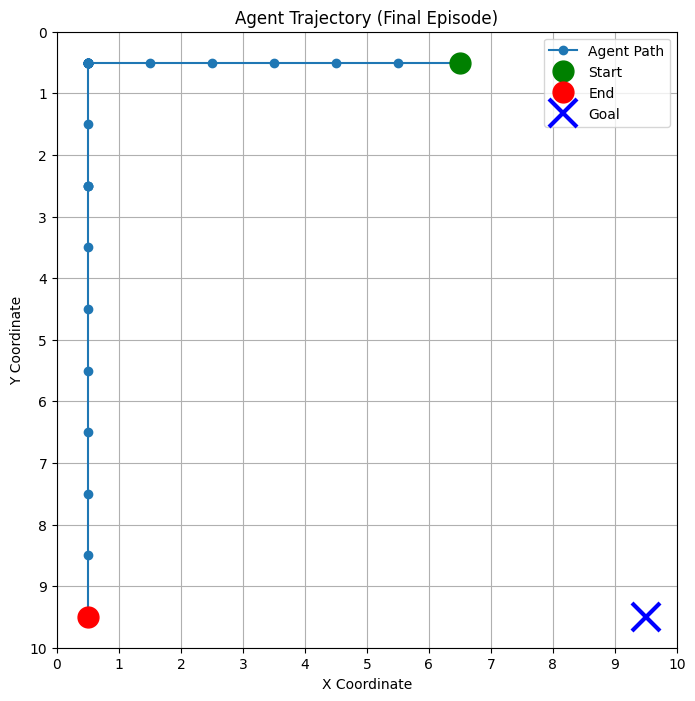

Trajectory plot saved to trajectory.png


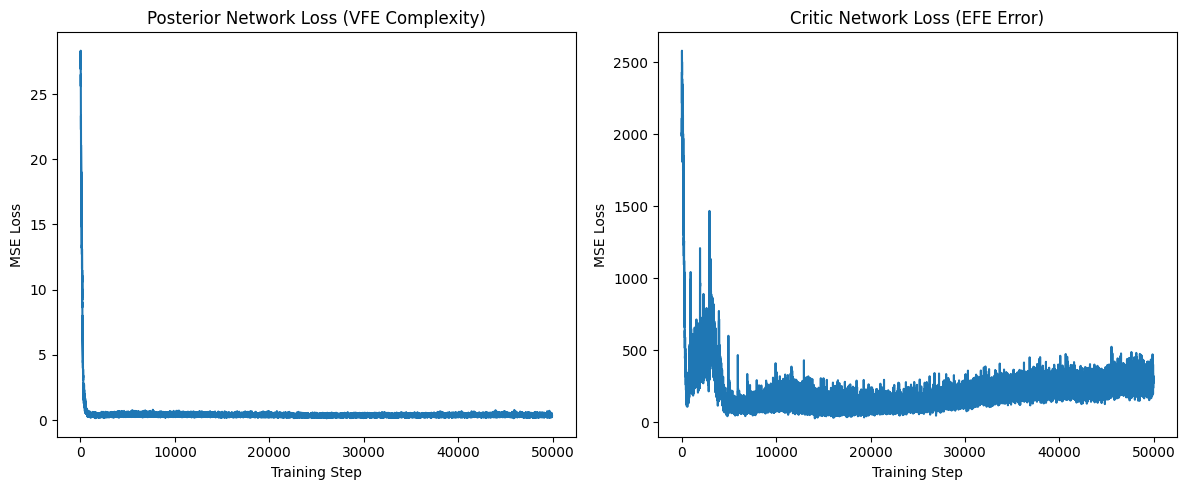

Learning curves plot saved to learning_curves.png


In [ ]:
# --- Visualization ---
plot_trajectory(all_trajectories[-1], env.size, env.goal_location)
plot_losses(posterior_losses, critic_losses)